#🧠 GUIA PRÁTICO PARA IMPLEMENTAÇÃO DAS PINNs

## 🌡️ Equação do Calor - Unidimensional

---


### 🔹 **1. Formulação do Problema**

Vamos agora implementar uma PINN para resolver um problema clássico: a **equação do calor unidimensional**.

**Equação de Calor 1D:**

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}, \quad x \in [0, L], \quad t \in [0, T_{final}]$$

**Condições:**

* **Inicial:** $T(x, 0) = T_{inicial}(x)$
* **Contorno:** $T(0, t) = T_{esquerda}(t)$, $T(L, t) = T_{direita}(t)$
    
**Objetivo:**

Aproximar a solução $T(x, t)$ usando uma Rede Neural Informada por Física (PINN).

### 🔹 **2. Definição do Domínio**

Neste passo, definimos os parâmetros do domínio espacial e temporal, além da difusividade térmica do material. Também criamos os pontos de amostragem no espaço e no tempo, que servirão como entrada para a rede neural.

In [ ]:
import numpy as np

# Parâmetros do domínio
L = 1.0  # Comprimento do domínio espacial
T_max = 0.5  # Tempo total de simulação
alpha = 0.01  # Difusividade térmica

# Pontos de amostragem no espaço e tempo
N_x = 50
N_t = 50

# Malha espacial e temporal
x = np.linspace(0, L, N_x).reshape(-1, 1)
t = np.linspace(0, T_max, N_t).reshape(-1, 1)
X, T = np.meshgrid(x, t)

# Conversão dos dados para entrar na rede neural (par ordenado x, t)
X_input = np.hstack((X.flatten()[:, None], T.flatten()[:, None]))

### 🔹 **3. Condições Iniciais e de Contorno**

In [ ]:
# Condições inicial:
T0 = np.sin(np.pi * x)  # Temperatura inicial

# Condições de contorno:
T_L = 0.0  # Temperatura na borda esquerda
T_R = 0.0  # Temperatura na borda direita

### 🔹 **4. Definição da Rede Neural**

In [ ]:
import tensorflow as tf

# Definição da arquitetura da PINN (4 camadas escondidas com 20 neurônios em cada)

class PINN(tf.keras.Model):
    def __init__(self):
        super(PINN, self).__init__()
        self.hidden = [
            tf.keras.layers.Dense(20, activation='tanh') for _ in range(4)
        ]
        self.output_layer = tf.keras.layers.Dense(1)

    def call(self, inputs):
        x = inputs
        for layer in self.hidden:
            x = layer(x)
        return self.output_layer(x)

### 🔹 **5. Função de Perda**

A função de perda combina três termos:

- O resíduo da equação de calor
- A condição inicial  
- As condições de contorno  

A equação da função de perda total é dada por:

$$
\mathcal{L} = \mathcal{L}_{res} + \mathcal{L}_{ic} + \mathcal{L}_{bc}
$$

Onde:

- $\mathcal{L}_{res}$ é o resíduo da equação de calor:

$$
\mathcal{L}_{res} = \frac{1}{N_f} \sum_{i=1}^{N_f} \left( \frac{\partial T}{\partial t} - \alpha \frac{\partial^2 T}{\partial x^2} \right)^2
$$

- $\mathcal{L}_{ic}$ é o erro nas condições iniciais:

$$
\mathcal{L}_{ic} = \frac{1}{N_0} \sum_{i=1}^{N_0} \left( T(x_i, 0) - T_0(x_i) \right)^2
$$

- $\mathcal{L}_{bc}$ é o erro nas condições de contorno:

$$
\mathcal{L}_{bc} = \frac{1}{N_b} \sum_{i=1}^{N_b} \left( T(0, t_i)^2 + T(L, t_i)^2 \right)
$$

O objetivo do treinamento é minimizar $\mathcal{L}$, forçando a rede neural a respeitar a física do problema.


In [ ]:
# Definindo a Função de perda

def loss_fn(model, X_input, x, t, T0, T_L, T_R):   # a função loss function é o núcleo das PINNs
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X_input)
        T_pred = model(X_input)

    # Gradientes da saída com relação às entradas
        T_x = tape.gradient(T_pred, X_input)[:, 0:1]    # Derivada ∂T/∂x
    T_t = tape.gradient(T_pred, X_input)[:, 1:2]        # Derivada ∂T/∂t
    T_xx = tape.gradient(T_x, X_input)[:, 0:1]          # Derivada segunda ∂²T/∂x²

    # Resíduo da equação de calor
    f_res = T_t - alpha * T_xx
#O objetivo da PINN é minimizar este resíduo para garantir que a solução da rede satisfaça a equação de calor.

    # Condições iniciais
    input0 = tf.concat([x, tf.zeros_like(x)], axis=1)
    T0_pred = model(input0)
    loss_ic = tf.reduce_mean(tf.square(T0_pred - T0))

    # Condições de contorno
    TL_pred = model(tf.concat([tf.zeros_like(t), t], axis=1))
    TR_pred = model(tf.concat([tf.ones_like(t) * L, t], axis=1))
    loss_bc = tf.reduce_mean(tf.square(TL_pred - T_L)) + tf.reduce_mean(tf.square(TR_pred - T_R))

    # Resíduo da equação de calor
    loss_res = tf.reduce_mean(tf.square(f_res))

    # Perda total
    return loss_res + loss_ic + loss_bc

### 🔹 **6. Treinamento do Modelo**

Agora que já definimos nossa função de perda, é hora de treinar a rede para que ela aprenda a resolver a equação de calor.

-> Aqui usamos o otimizador `Adam`, que é uma escolha bastante comum em problemas com redes neurais, com uma taxa de aprendizado de `0.001`.

*O processo de treinamento roda por 1000 épocas, sendo acompanhado a cada 100 épocas.*

-> A cada época, calculamos a perda total, depois usamos o `GradientTape` do TensorFlow para obter os gradientes.

-> Com esses gradientes em mãos, o otimizador ajusta os pesos da rede na direção de minimizar a perda.

In [ ]:
# Treinamento do modelo
model = PINN()  # Chama a rede neural
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

epochs = 1000
for epoch in range(epochs):
    with tf.GradientTape() as tape:
      # Calcula a perda total
        loss = loss_fn(model, tf.convert_to_tensor(X_input, dtype=tf.float32),
                       tf.convert_to_tensor(x, dtype=tf.float32),
                       tf.convert_to_tensor(t, dtype=tf.float32),
                       tf.convert_to_tensor(T0, dtype=tf.float32),
                       T_L, T_R)

    #Atualiza os pesos da rede
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Exibe a perda a cada 100 épocas
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

Epoch 0, Loss: 1.615993857383728
Epoch 100, Loss: 0.3250375986099243
Epoch 200, Loss: 0.11128881573677063
Epoch 300, Loss: 0.02136877551674843
Epoch 400, Loss: 0.012353065423667431
Epoch 500, Loss: 0.008242595940828323
Epoch 600, Loss: 0.005624981597065926
Epoch 700, Loss: 0.0038581020198762417
Epoch 800, Loss: 0.0026362785138189793
Epoch 900, Loss: 0.0017849714495241642


### 🔹 **7. Visualização dos Resultados**

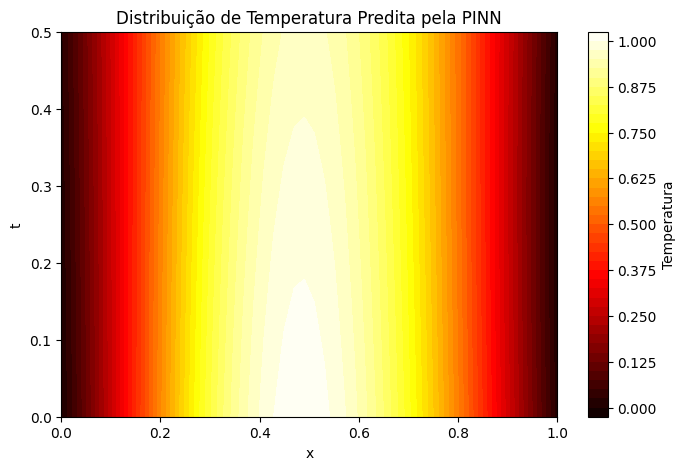

In [ ]:
# Geração das predições na malha
T_pred = model(tf.convert_to_tensor(X_input, dtype=tf.float32)).numpy().reshape(N_t, N_x)

import matplotlib.pyplot as plt

# Gráfico da temperatura
plt.figure(figsize=(8, 5))
plt.contourf(X, T, T_pred, levels=50, cmap='hot')
plt.colorbar(label="Temperatura")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Distribuição de Temperatura Predita pela PINN")
plt.show()